In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import os
os.chdir('/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/')

[warn] Missing dllm metrics.jsonl for /lustre/fast/fast/pmayilvahanan/Interplay-LM-Reasoning/results/dllm_eval/a2d_bd3lm_100M_20260221_145059/checkpoint-500 (skipping)


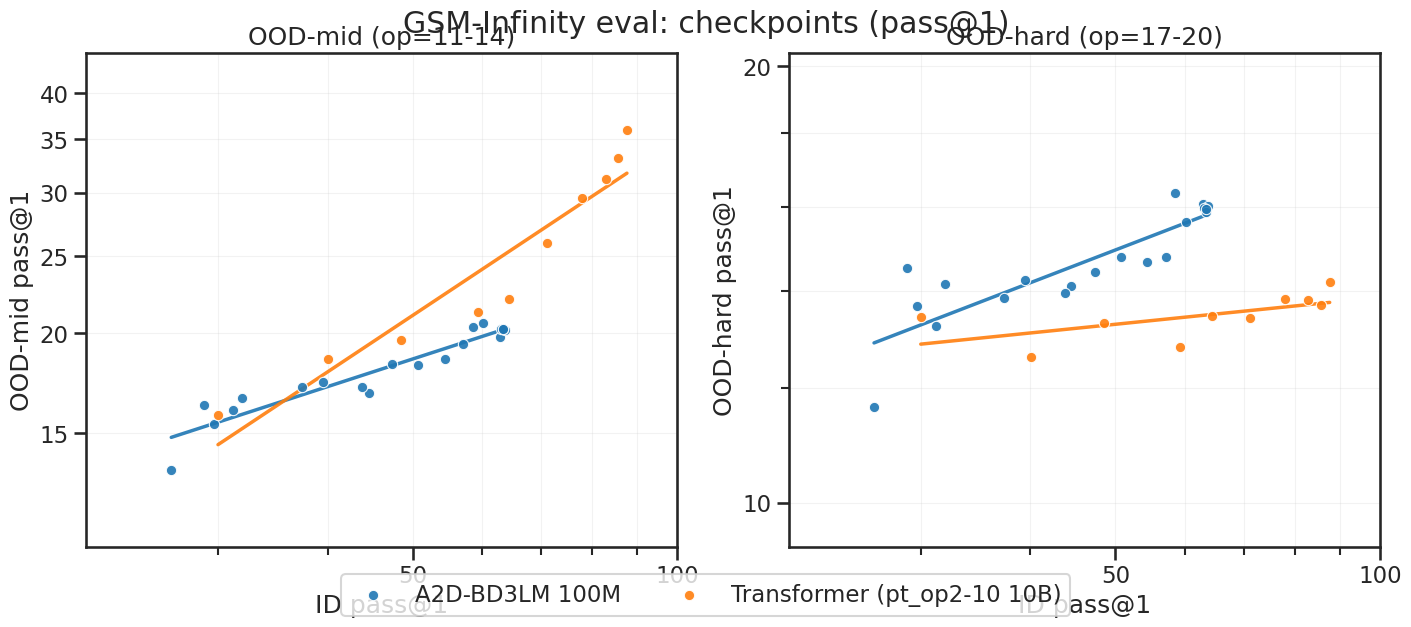

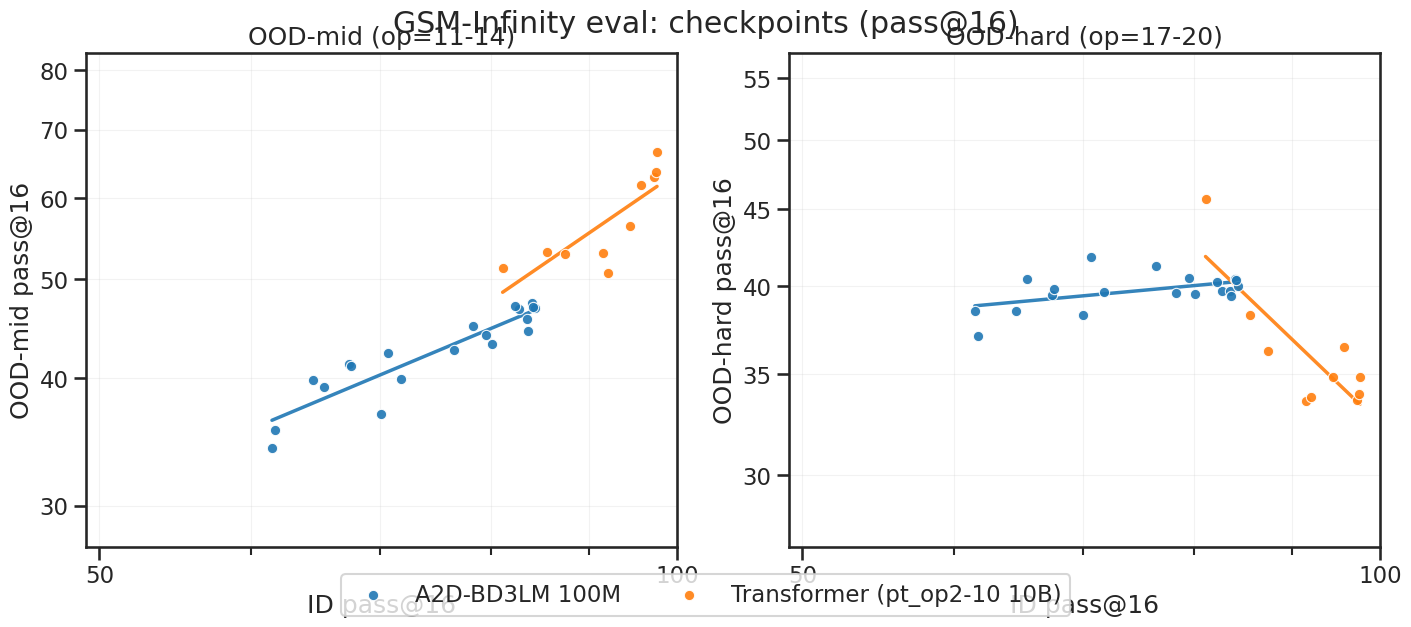

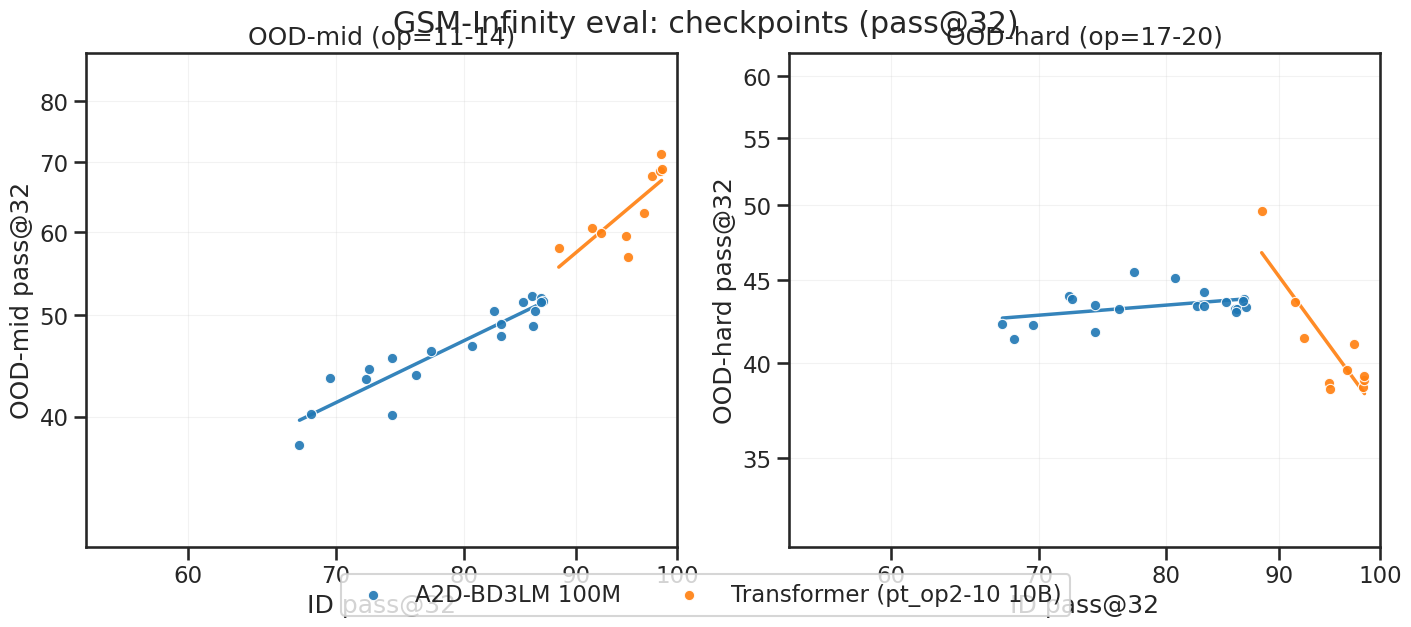

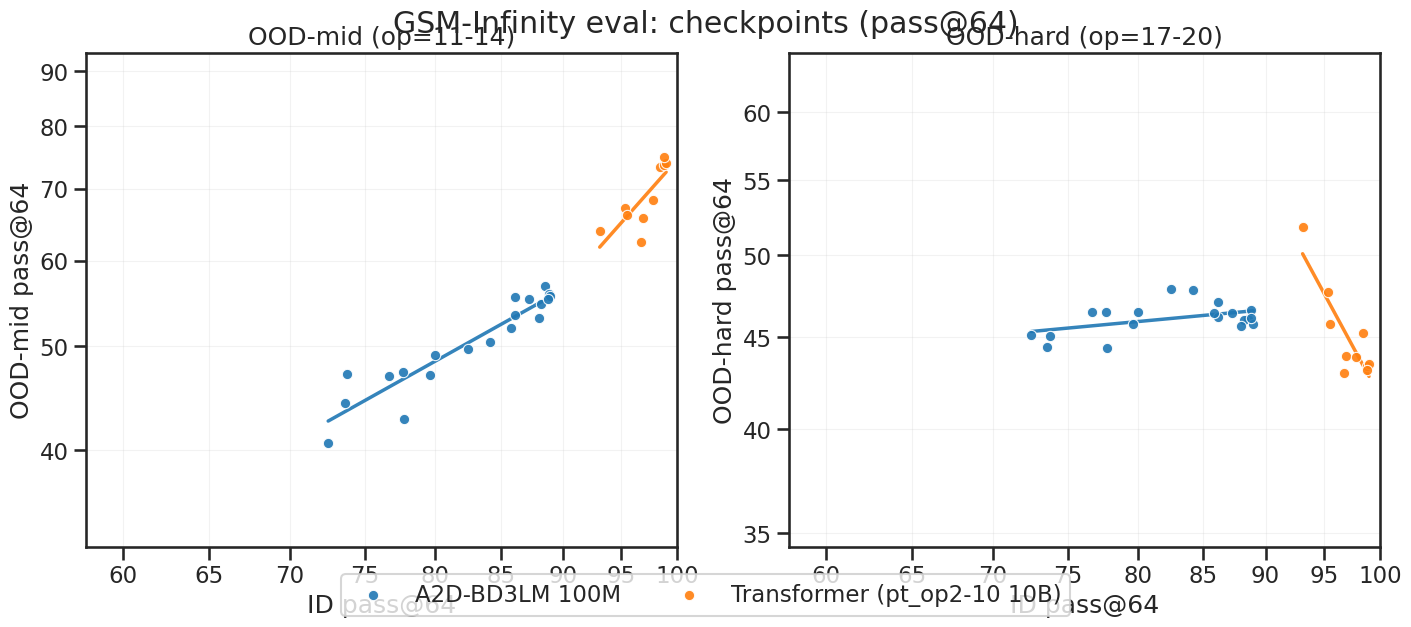

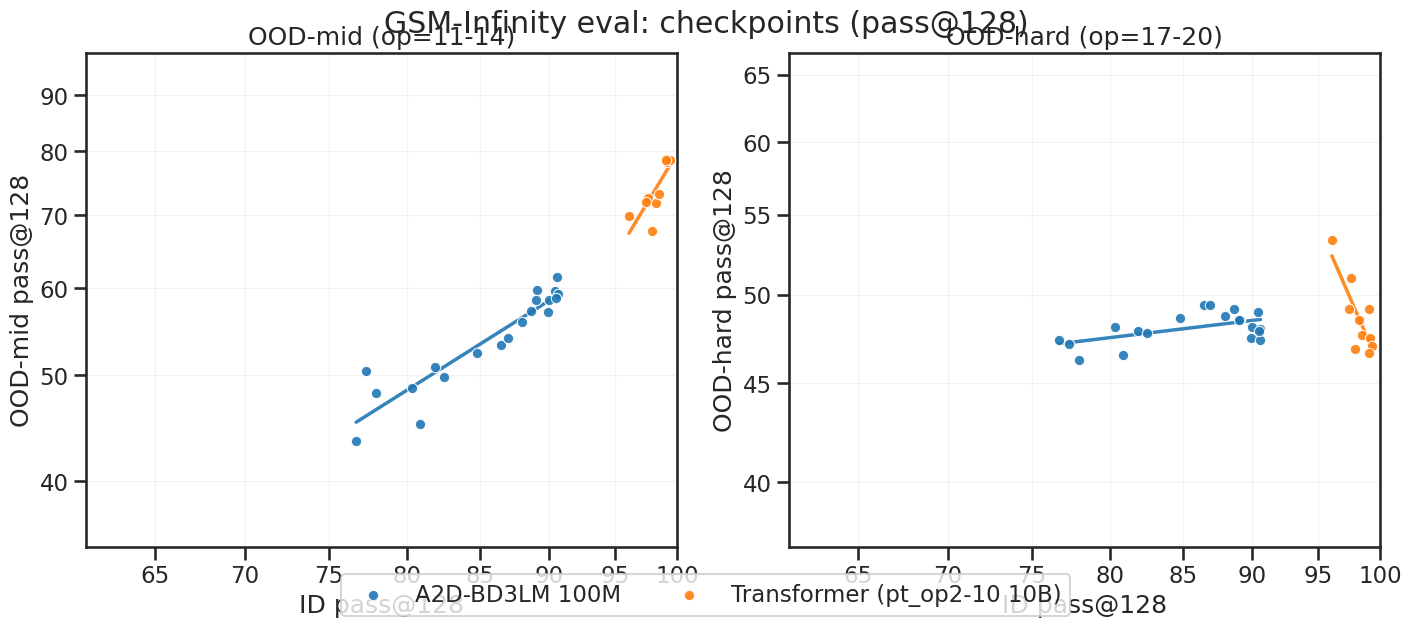

Saved plots to: /lustre/fast/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/figures/id_vs_ood


In [2]:
from process_eval_results import PROJECT_ROOT, load_eval_runs, plot_id_vs_ood_scatter

# Runs currently available (add MDLM once its eval finishes)
run_specs = [
    {
        "run_type": "transformer",
        "run_name": "pt_op2-10_10B_alltemps_20260213_233838",
        "label": "Transformer (pt_op2-10 10B)",
    },
    {
        "run_type": "dllm",
        "run_name": "a2d_bd3lm_100M_20260221_145059",
        "label": "A2D-BD3LM 100M",
    },
    # {
    #     "run_type": "dllm",
    #     "run_name": "a2d_mdlm_100M_20260221_144133",
    #     "label": "A2D-MDLM 100M",
    # },
]

k_plot = [1, 16, 32, 64, 128]

df = load_eval_runs(run_specs, k_values=k_plot, to_percent=True, verbose=True)
df.head()

save_dir = PROJECT_ROOT / "analyze" / "figures" / "id_vs_ood"
plot_id_vs_ood_scatter(
    df,
    k_values=k_plot,
    title_prefix="GSM-Infinity eval: checkpoints",
    save_dir=save_dir,
)
print(f"Saved plots to: {save_dir}")
